In [1]:
# Rode esta célula uma vez para instalar dependências no Python do kernel
!pip install pandas matplotlib -q

In [2]:
import sys
import subprocess
from pathlib import Path

# Instala no mesmo Python que o kernel está usando
subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas", "matplotlib", "-q"])

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/Users/jenuan/Documents/Projetos tech/Cripto/LP-Screener-Sheets/lp-bot-python").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from lpbot.executor import run_once
from lpbot.analytics import compute_basic_metrics, get_events_table
from lpbot.storage.log_store import load_all_events
from lpbot.storage.state_store import load_portfolio_state
from lpbot.analytics import compute_basic_metrics, get_wallet_summary

In [10]:
# roda um ciclo do bot
run_once()

# métricas agregadas (inclui cash disponível)
metrics = compute_basic_metrics()
metrics

{'total_events': 6.0,
 'total_trades': 6.0,
 'total_realized_pnl_usd': 0.0,
 'realized_pnl_usd': 0.0,
 'total_fees_usd': 0.0,
 'total_il_usd': 0.0,
 'cash_available_usd': 0.0,
 'invested_usd': 100.0,
 'wallet_total_value_usd': 100.0,
 'open_positions': 5.0}

In [11]:

events = load_all_events()
len(events)

6

In [12]:
events = load_all_events()  # carrega do SQLite (rode a célula de imports antes)
df_events = pd.DataFrame([e.__dict__ for e in events])
df_events.tail(10)  # <-- deixar essa linha por último para ver a tabela


,timestamp,event_type,position_id,description,delta_cash_usd,delta_realized_pnl_usd,delta_unrealized_pnl_usd,delta_fees_usd,delta_il_usd,metadata
0,2026-03-12 21:52:06.953500,EventType.OPEN_POSITION,UNKNOWN::UNKNOWN::2026-03-12T21:52:06.953500,Opened position: APR above threshold and capac...,-20.0,0.0,0.0,0.0,0.0,{'candidate': {'Chain': 'Last Update: 3/12/202...
1,2026-03-12 21:55:49.877672,EventType.OPEN_POSITION,UNKNOWN::UNKNOWN::2026-03-12T21:55:49.877672,Opened position: APR above threshold and capac...,-20.0,0.0,0.0,0.0,0.0,{'candidate': {'Chain': 'Last Update: 3/12/202...
2,2026-03-12 22:14:01.240119,EventType.OPEN_POSITION,UNKNOWN::UNKNOWN::2026-03-12T22:14:01.240119,Opened position: APR above threshold and capac...,-20.0,0.0,0.0,0.0,0.0,{'candidate': {'Chain': 'Last Update: 3/12/202...
3,2026-03-12 22:14:30.288224,EventType.OPEN_POSITION,UNKNOWN::UNKNOWN::2026-03-12T22:14:30.288224,Opened position: APR above threshold and capac...,-20.0,0.0,0.0,0.0,0.0,{'candidate': {'Chain': 'Last Update: 3/12/202...
4,2026-03-12 22:17:03.064834,EventType.OPEN_POSITION,UNKNOWN::UNKNOWN::2026-03-12T22:17:03.064834,Opened position: APR above threshold and capac...,-20.0,0.0,0.0,0.0,0.0,{'candidate': {'Chain': 'Last Update: 3/12/202...
5,2026-03-12 22:19:51.112766,EventType.OPEN_POSITION,UNKNOWN::UNKNOWN::2026-03-12T22:19:51.112766,Opened position: APR above threshold and capac...,-20.0,0.0,0.0,0.0,0.0,{'candidate': {'Chain': 'Last Update: 3/12/202...


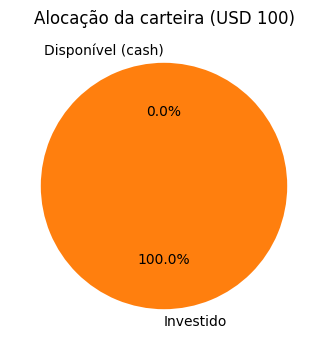

([0.0, 100.0], ['Disponível (cash)', 'Investido'])

In [8]:
from lpbot.storage.state_store import load_portfolio_state
import matplotlib.pyplot as plt

INITIAL_CAPITAL = 100.0

state = load_portfolio_state()
cash = state.cash_usd
invested = max(INITIAL_CAPITAL - cash, 0.0)

labels = ["Disponível (cash)", "Investido"]
values = [cash, invested]

fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(values, labels=labels, autopct="%1.1f%%", startangle=90)
ax.set_title("Alocação da carteira (USD 100)")
plt.show()  # <-- CHAMAR plt.show() para garantir que o gráfico apareça

values, labels  # opcional, para ver os números


In [9]:
from lpbot.storage.state_store import load_portfolio_state

state = load_portfolio_state()
cash = state.cash_usd
invested = sum(p.notional_usd for p in state.positions)

cash, invested, len(state.positions)

(0.0, 100.0, 5)